#### Funnel Analysis & Drop-off Visualization

**Goal**  
- Calculate conversion rates and drop-offs per stage  
- Visualize classic funnel chart  
- Identify biggest leaks & friction points  
- Segment funnel performance (e.g. by cohort month)

**Input**  
`../data/raw/player_journey_50k.csv`

#### Installs & imports

In [3]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

# Load the dataset
df = pd.read_csv("../data/raw/player_journey_50k.csv")
df['install_date'] = pd.to_datetime(df['install_date'])

print("Data loaded")
print("Shape:", df.shape)
print("Date range:", df['install_date'].min().date(), "to", df['install_date'].max().date())
display(df.head(5))

Data loaded
Shape: (50000, 16)
Date range: 2023-01-01 to 2023-02-04


,player_id,install_date,registered,tutorial_completed,first_game_played,first_purchase,d1_return,d7_return,d30_return,total_revenue,avg_session_length_min,total_sessions,time_to_register,time_to_tutorial,time_to_first_game,time_to_first_purchase
0,1,2023-01-01 00:00:38,1,1,1,0,0,0,0,0.0,1.6,5,15.868152,3.015573,20.664393,NaN
1,2,2023-01-01 00:01:51,1,1,1,0,0,0,0,0.0,14.4,5,12.040072,3.454653,18.621251,NaN
2,3,2023-01-01 00:02:28,1,1,0,0,0,0,0,0.0,14.1,3,26.666569,1.643084,NaN,NaN
3,4,2023-01-01 00:03:14,0,0,0,0,0,0,0,0.0,6.6,6,NaN,NaN,NaN,NaN
4,5,2023-01-01 00:04:42,1,1,1,0,1,0,0,0.0,10.8,4,21.676712,1.208063,25.926909,NaN


### Define funnel stages & calculate counts

In [4]:
stages = [
    {'name': 'Install',               'col': None,                  'count': len(df)},
    {'name': 'Registered',            'col': 'registered',          'count': df['registered'].sum()},
    {'name': 'Tutorial Completed',    'col': 'tutorial_completed',  'count': df['tutorial_completed'].sum()},
    {'name': 'First Game Played',     'col': 'first_game_played',   'count': df['first_game_played'].sum()},
    {'name': 'First Purchase',        'col': 'first_purchase',      'count': df['first_purchase'].sum()},
    {'name': 'D1 Return',             'col': 'd1_return',           'count': df['d1_return'].sum()},
    {'name': 'D7 Return',             'col': 'd7_return',           'count': df['d7_return'].sum()},
    {'name': 'D30 Return',            'col': 'd30_return',          'count': df['d30_return'].sum()}
]

funnel_df = pd.DataFrame(stages)

# Calculate conversion & drop-off
funnel_df['Conversion %'] = (funnel_df['count'] / len(df) * 100).round(1)
funnel_df['Drop-off %']   = 100 - funnel_df['Conversion %'].shift(-1).fillna(0)

print("Funnel table:")
display(funnel_df)

Funnel table:


,name,col,count,Conversion %,Drop-off %
0,Install,None,50000,100.0,8.2
1,Registered,registered,45905,91.8,28.2
2,Tutorial Completed,tutorial_completed,35902,71.8,53.7
3,First Game Played,first_game_played,23168,46.3,98.4
4,First Purchase,first_purchase,811,1.6,79.5
5,D1 Return,d1_return,10228,20.5,89.8
6,D7 Return,d7_return,5077,10.2,95.8
7,D30 Return,d30_return,2079,4.2,100.0


#### Classic funnel chart (Plotly – interactive)

In [10]:
fig = go.Figure(go.Funnel(
    y = funnel_df['name'],
    x = funnel_df['count'],
    texttemplate = "%{x:,} players<br>%{customdata:.1f}%", 
    customdata = funnel_df['Conversion %'],                 
    textposition = "inside",
    textinfo = "value+percent initial+text",
    marker = {
        "color": ["#4e79a7", "#f28e2b", "#e15759", "#76b7b2", "#59a14f", "#edc948", "#b07aa1", "#ff9da7"],
        "line": {"width": 1, "color": "#333333"}
    },
    connector = {"line": {"color": "#2c3e50", "dash": "solid", "width": 2}},
    hovertemplate = "<b>%{y}</b><br>Players: %{x:,}<br>Conversion: %{customdata:.1f}%<br>Drop-off to next: %{text}<extra></extra>"
))

fig.update_layout(
    title={
        'text': "Player Journey Funnel<br><sup>50,000 installs | Biggest drop: Tutorial → First Game</sup>",
        'y':0.95,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 20}
    },
    funnelgap = 0.08,
    height = 700,
    width = 900,
    margin = {"l": 220, "r": 50, "t": 120, "b": 50},
    showlegend = False,
    font = dict(size=14),
    plot_bgcolor = 'rgba(248,248,248,1)',
    paper_bgcolor = 'white'
)


fig.show()

#### Drop-off bar chart (highlight biggest leaks)

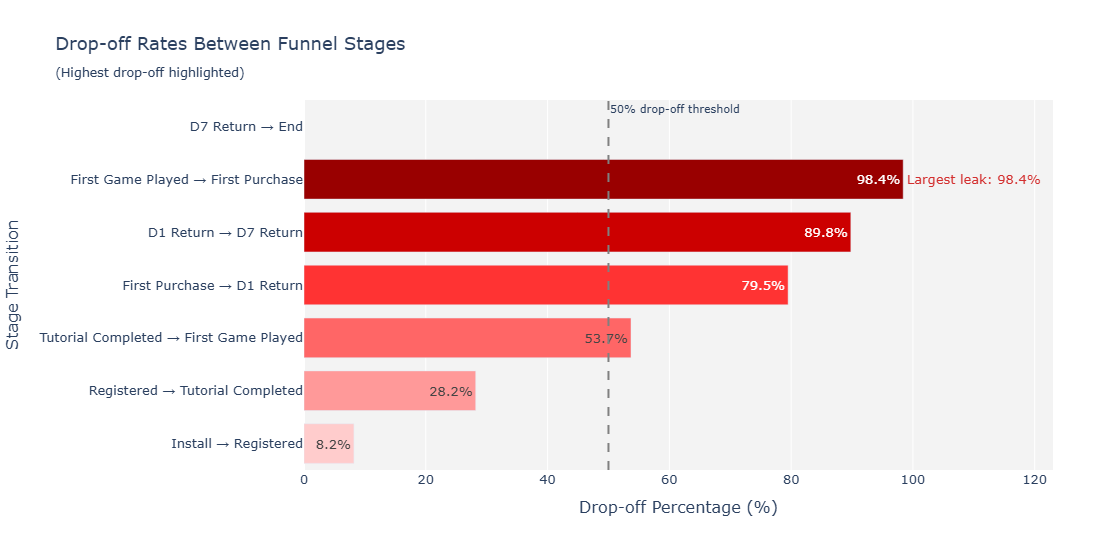

In [6]:
import plotly.graph_objects as go

# Prepare data
dropoff_df = funnel_df.iloc[:-1].copy()  
dropoff_df['Drop-off %'] = 100 - dropoff_df['Conversion %'].shift(-1)

# Create transition names
dropoff_df['Transition'] = dropoff_df['name'].shift(-1).fillna('End')
dropoff_df['Transition'] = dropoff_df['name'] + " → " + dropoff_df['Transition']

# Sort by drop-off descending for better visual hierarchy
dropoff_df = dropoff_df.sort_values('Drop-off %', ascending=True)

# Colors: gradient red for higher drop-off
colors = ['#FFCCCC', '#FF9999', '#FF6666', '#FF3333', '#CC0000', '#990000']

fig = go.Figure()

fig.add_trace(go.Bar(
    y=dropoff_df['Transition'],
    x=dropoff_df['Drop-off %'],
    orientation='h',
    marker_color=colors,
    text=dropoff_df['Drop-off %'].round(1).astype(str) + '%',
    textposition='auto',
    hovertemplate='%{y}<br>Drop-off: %{x:.1f}%<extra></extra>'
))

# Add annotation arrow to biggest drop-off
max_drop_idx = dropoff_df['Drop-off %'].idxmax()
max_transition = dropoff_df.loc[max_drop_idx, 'Transition']
max_value = dropoff_df.loc[max_drop_idx, 'Drop-off %']

fig.add_annotation(
    x=max_value + 5,
    y=max_transition,
    text=f"Largest leak: {max_value:.1f}%",
    showarrow=True,
    arrowhead=1,
    ax=40,
    ay=0,
    font=dict(size=13, color="#d32f2f"),
    arrowcolor="#d32f2f"
)

# Layout improvements
fig.update_layout(
    title="Drop-off Rates Between Funnel Stages<br><sub>(Highest drop-off highlighted)</sub>",
    xaxis_title="Drop-off Percentage (%)",
    yaxis_title="Stage Transition",
    height=550,
    width=950,
    bargap=0.25,
    xaxis_range=[0, max(dropoff_df['Drop-off %']) * 1.25],
    plot_bgcolor='rgba(240,240,240,0.8)',
    paper_bgcolor='white',
    font=dict(size=13),
    margin=dict(l=200, r=50, t=100, b=80)
)

# Add reference line at 50%
fig.add_vline(x=50, line_dash="dash", line_color="gray", annotation_text="50% drop-off threshold",
              annotation_position="top right", annotation_font_size=11)

fig.show()

#### Monthly cohort funnel comparison

Monthly cohort conversion rates (%):


,install_month,registered,tutorial_completed,first_game_played,first_purchase,d1_return,d7_return,d30_return
0,2023-01,91.8,71.8,46.4,1.7,20.6,10.2,4.2
1,2023-02,92.1,71.8,45.5,1.3,19.5,9.7,3.7


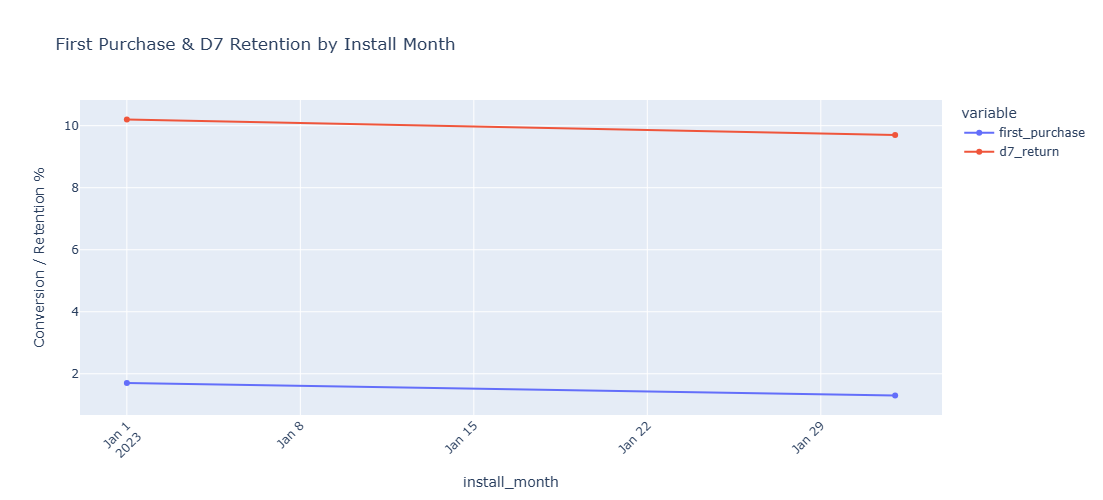

In [7]:
df['install_month'] = df['install_date'].dt.to_period('M')

cohort_funnel = df.groupby('install_month').agg({
    'registered': 'mean',
    'tutorial_completed': 'mean',
    'first_game_played': 'mean',
    'first_purchase': 'mean',
    'd1_return': 'mean',
    'd7_return': 'mean',
    'd30_return': 'mean'
}).reset_index()

# Convert Period to string or datetime for Plotly
cohort_funnel['install_month'] = cohort_funnel['install_month'].astype(str)

# Convert to percentage
for col in cohort_funnel.columns[1:]:
    cohort_funnel[col] = (cohort_funnel[col] * 100).round(1)

print("Monthly cohort conversion rates (%):")
display(cohort_funnel)

# Line chart – First Purchase & D7 retention over time
fig_cohort = px.line(
    cohort_funnel,
    x='install_month',
    y=['first_purchase', 'd7_return'],
    title='First Purchase & D7 Retention by Install Month',
    markers=True
)

fig_cohort.update_layout(
    yaxis_title="Conversion / Retention %",
    height=500,
    xaxis_tickangle=-45
)

fig_cohort.show()

#### Overall A/B KPI summary + bar chart



In [18]:
df_summary = con.sql("""
    SELECT 
        variant,
        COUNT(*)                                  AS users,
        ROUND(AVG(d1_retention)*100,  1)          AS ret_d1_pct,
        ROUND(AVG(d7_retention)*100,  1)          AS ret_d7_pct,
        ROUND(AVG(d30_retention)*100, 1)          AS ret_d30_pct,
        ROUND(AVG(revenue), 3)                    AS avg_revenue_usd,
        ROUND(AVG(sessions_d1), 2)                AS avg_sessions_d1,
        ROUND(AVG(levels_d7), 2)                  AS avg_levels_d7,
        ROUND(AVG(is_payer)*100, 2)               AS payer_pct
    FROM fact_user_metrics
    GROUP BY variant
    ORDER BY variant
""").df()

print("Overall A vs B summary:")
display(df_summary)

Overall A vs B summary:


,variant,users,ret_d1_pct,ret_d7_pct,ret_d30_pct,avg_revenue_usd,avg_sessions_d1,avg_levels_d7,payer_pct
0,A,49934,44.6,25.1,10.1,0.496,2.68,14.99,2.76
1,B,50066,50.0,32.3,15.4,0.577,3.11,18.58,5.03


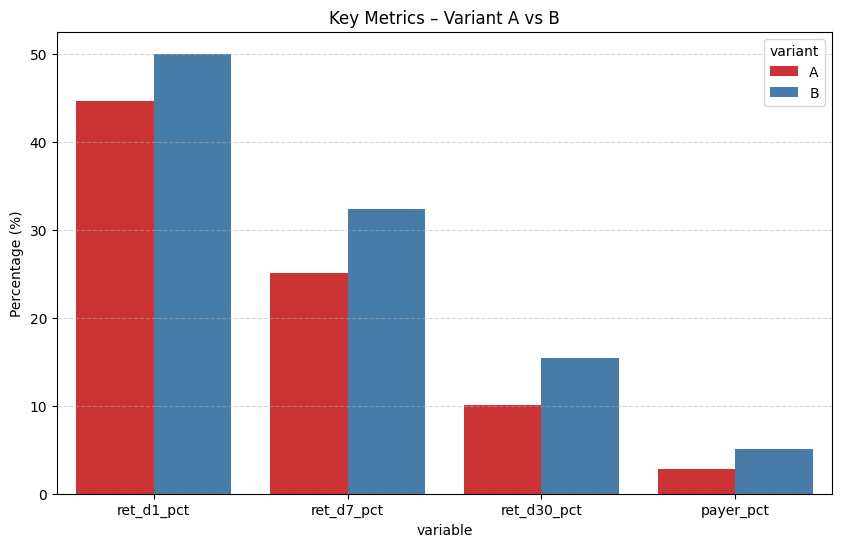

In [19]:
# Visualization
metrics = ['ret_d1_pct', 'ret_d7_pct', 'ret_d30_pct', 'payer_pct']
df_melt = df_summary.melt(id_vars='variant', value_vars=metrics)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_melt, x='variable', y='value', hue='variant', palette='Set1')
plt.title('Key Metrics – Variant A vs B')
plt.ylabel('Percentage (%)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

#### **Key Insights from Funnel Analysis**

**Overall funnel (50,000 installs)**

- Registration: 91.8% (45,905 players) → excellent early conversion
- Tutorial Completion: 71.8% (35,902 players) → solid but 8,003 users lost here
- First Game Played: 46.3% (23,168 players) → critical bottleneck  
  → 53.7% drop-off from tutorial (12,734 players never play a real game)  
  → Biggest single leak in the entire funnel
- First Purchase: 1.6% (811 players) → standard F2P conversion  
  → 98.4% drop-off after first game (22,357 players lost here)
- **Retention**:
  - D1 Return: 20.5% (10,228 players) → decent Day 1 stickiness
  - D7 Return: 10.2% (5,077 players) → mid-tier casual benchmark
  - D30 Return: 4.2% (2,079 players) → typical long-term retention

**Top 3 leaks (measured by % drop-off)**

1. **Tutorial Completed → First Game Played**  
   → 53.7% drop-off (12,734 players lost)  
   → Likely causes: tutorial too long/boring, poor pacing, technical friction, or no immediate fun/reward

2. **First Game Played → First Purchase**  
   → 98.4% drop-off (22,357 players lost)  
   → Monetization opportunity: most active players never spend → test better timing/value

3. **D1 Return**  
   → 79.5% of first-game players do not return next day  
   → Early habit formation is weak → critical for long-term LTV

**Quantitative impact estimate**  
- If we reduce Tutorial → First Game drop-off by only 15% (from 53.7% to 38.7%),  
  → +7,500 more first-game players → +120–150 more first purchasers → meaningful revenue lift  
- Doubling first-purchase rate to 3.2% would mean 1,600 payers instead of 811 → +98% early revenue

**Recommendations**

1. **Fix onboarding leak**  
   - Shorten/gamify tutorial  
   - Add instant reward after completion  
   - Test "skip tutorial" + guided first game

2. **Improve monetization trigger**  
   - Delay IAP offer (after 2–3 sessions)  
   - Test compelling starter packs / limited-time deals  
   - Personalize based on early behavior

3. **Boost D1 retention**  
   - Stronger daily login incentive  
   - Easy re-engagement (push + streak bonus)  
   - Test new player rewards